# Data Exploration

This notebook is a simple first look at the training data.

We only use `data/Input` for now because that is the paired dataset for training:

- `data/Input/real`: real face images
- `data/Input/comic`: matching comic-style target images

The goal is to answer four basic questions before modeling:

1. Do we have real/comic image pairs?
2. Do the filenames match correctly?
3. What do the image pairs look like?
4. What image size should we use for training?

In [21]:
from pathlib import Path
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Use only the paired input dataset in this notebook.
DATA_DIR = Path("../data/Input")
REAL_DIR = DATA_DIR / "real"
COMIC_DIR = DATA_DIR / "comic"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

## 1. Find the Image Pairs

For paired training, every real image should have a comic image with the same filename.

Example:

`real/123.jpg` should match `comic/123.jpg`.

In [22]:
def sort_key(path):
    """Sort 2.jpg before 10.jpg when filenames are numbers."""
    stem = Path(path).stem
    return int(stem) if stem.isdigit() else stem


def list_images(folder):
    return sorted(
        [p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS],
        key=sort_key,
    )


real_images = list_images(REAL_DIR)
comic_images = list_images(COMIC_DIR)

real_names = {p.name for p in real_images}
comic_names = {p.name for p in comic_images}
paired_names = sorted(real_names & comic_names, key=sort_key)

pairs = [(REAL_DIR / name, COMIC_DIR / name) for name in paired_names]
missing_comics = real_names - comic_names
missing_reals = comic_names - real_names

print(f"Real images:   {len(real_images):,}")
print(f"Comic images:  {len(comic_images):,}")
print(f"Image pairs:   {len(pairs):,}")
print(f"Missing comic: {len(missing_comics):,}")
print(f"Missing real:  {len(missing_reals):,}")

assert len(pairs) > 0, "No image pairs found. Check the data/Input folder."
assert len(missing_comics) == 0 and len(missing_reals) == 0, "Some filenames do not match."

Real images:   10,000
Comic images:  10,000
Image pairs:   10,000
Missing comic: 0
Missing real:  0


## 2. Load One Image Pair

OpenCV loads images in BGR order, but matplotlib expects RGB. The helper below fixes that so images display correctly.

In [23]:
def load_rgb(path):
    image = cv2.imread(str(path))
    if image is None:
        raise ValueError(f"Could not read image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


example_real_path, example_comic_path = pairs[0]
example_real = load_rgb(example_real_path)
example_comic = load_rgb(example_comic_path)

print("Example pair:", example_real_path.name)
print("Real image shape: ", example_real.shape)
print("Comic image shape:", example_comic.shape)

Example pair: 0.jpg
Real image shape:  (512, 512, 3)
Comic image shape: (512, 512, 3)


## 3. Look at a Few Pairs

This is the most important part of the exploration. We want to visually confirm that each real image matches the comic image below it.

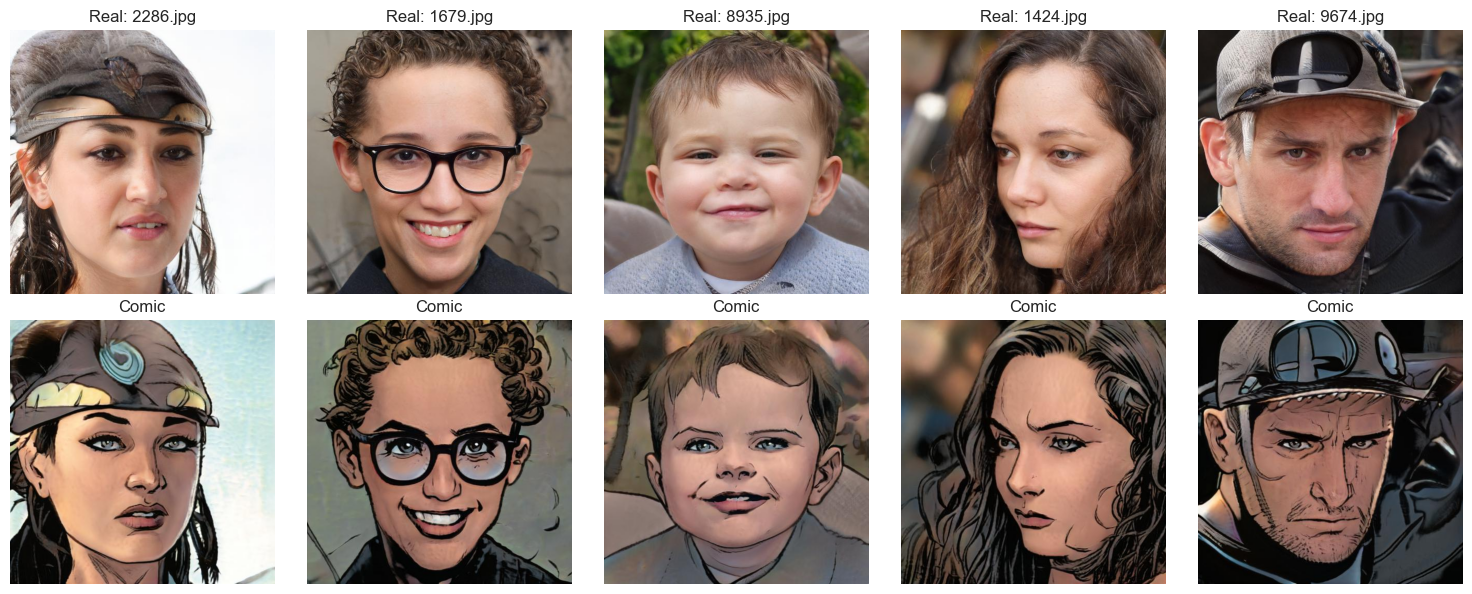

In [25]:
sample_pairs = random.sample(pairs, min(5, len(pairs)))

fig, axes = plt.subplots(2, len(sample_pairs), figsize=(3 * len(sample_pairs), 6))

for i, (real_path, comic_path) in enumerate(sample_pairs):
    axes[0, i].imshow(load_rgb(real_path))
    axes[0, i].set_title(f"Real: {real_path.name}")
    axes[0, i].axis("off")

    axes[1, i].imshow(load_rgb(comic_path))
    axes[1, i].set_title("Comic")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## 4. Check Image Sizes

GAN training is easier when all images have the same shape. We check a small sample first because it is fast and enough for initial exploration.

In [26]:
size_sample = random.sample(pairs, min(100, len(pairs)))

real_shapes = [load_rgb(real_path).shape for real_path, _ in size_sample]
comic_shapes = [load_rgb(comic_path).shape for _, comic_path in size_sample]

print("Unique real image shapes: ", sorted(set(real_shapes)))
print("Unique comic image shapes:", sorted(set(comic_shapes)))

if len(set(real_shapes)) == 1 and len(set(comic_shapes)) == 1:
    print("Good news: sampled images have consistent shapes.")
else:
    print("Some sampled images have different shapes, so resizing will be needed.")

Unique real image shapes:  [(512, 512, 3)]
Unique comic image shapes: [(512, 512, 3)]
Good news: sampled images have consistent shapes.


## 5. Preview Basic Preprocessing

For training, each image should become a fixed-size numeric array.

A simple first choice is:

1. Resize each image to `256 x 256`.
2. Scale pixel values from `0-255` to `-1 to 1`.

This is common for GANs because the final generator activation is often `tanh`, which also outputs values in `[-1, 1]`.

Before preprocessing: (512, 512, 3) 0 255
After preprocessing:  (256, 256, 3) -1.0 0.96862745


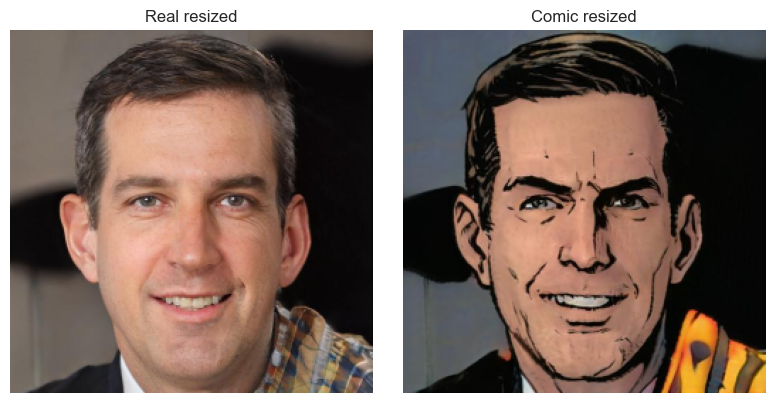

In [27]:
TRAIN_SIZE = 256


def preprocess(image, size=TRAIN_SIZE):
    resized = cv2.resize(image, (size, size), interpolation=cv2.INTER_AREA)
    normalized = resized.astype(np.float32) / 127.5 - 1.0
    return resized, normalized


real_path, comic_path = random.choice(pairs)
real_image = load_rgb(real_path)
comic_image = load_rgb(comic_path)

real_resized, real_normalized = preprocess(real_image)
comic_resized, comic_normalized = preprocess(comic_image)

print("Before preprocessing:", real_image.shape, real_image.min(), real_image.max())
print("After preprocessing: ", real_normalized.shape, real_normalized.min(), real_normalized.max())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(real_resized)
axes[0].set_title("Real resized")
axes[0].axis("off")

axes[1].imshow(comic_resized)
axes[1].set_title("Comic resized")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 6. Simple Takeaways

- The dataset has matching real/comic image pairs.
- The examples show the task clearly: convert a real face into a comic-style face.
- The sampled images have consistent shapes, which makes training easier.
- A simple training pipeline can resize images to `256 x 256` and normalize pixels to `[-1, 1]`.

Next step: build a dataset loader that returns `(real_image, comic_image)` pairs for the model.